# Solutions notebook · Machine Learning for Prediction

This notebook runs the chapter's two staged demonstrations (Examples 2.7 and 2.9), draws the three plots of Section 2.7, shows that the library agrees with the hand checks of Examples 2.1, 2.2, 2.3, and 2.5, and works the critique problems 2.10 to 2.13. Each section follows the four-verb story: what was generated, what was read, what was fixed, and what was validated. Every number here agrees with the chapter, the solutions document, and the solutions workbook.

**How to use it.** Restart the kernel and run all cells. Every cell runs clean. The data are written by the notebook itself, so no download is needed. Libraries: pandas, NumPy, scikit-learn, and matplotlib, all installed in Google Colab and in the Anaconda distribution.

**Conventions.** The split is 75/25, stratified by the outcome, with random_state 42. Cleaning steps are fitted on the training set only. The positive class is default. Accuracy is read beside the majority baseline. A missed default costs $9,000 and a refused good loan $1,200 (the credit team's assumptions). All companies are fictional.

**A note on versions.** The cells below assert the chapter's figures. They were produced with the library versions printed in the next cell. A different scikit-learn or NumPy version can, in rare cases, move one borderline loan across the 0.5 threshold and change a confusion-matrix count by one; if an assertion fails by one case, that is the cause, and the four verbs still apply to the number you see.

In [2]:
# Versions and settings. Run this cell first.
import platform, warnings
import numpy as np, pandas as pd, sklearn, matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
np.random.seed(2026)   # the data generator below uses its own fixed seed as well
print("Python", platform.python_version())
print("pandas", pd.__version__)
print("NumPy", np.__version__)
print("scikit-learn", sklearn.__version__)
print("matplotlib", matplotlib.__version__)

Python 3.12.3
pandas 3.0.5
NumPy 2.5.3
scikit-learn 1.9.1
matplotlib 3.11.2


## Section 0 · The data: Marram Lending's loan file

Marram Lending is a fictional consumer lender. The cell below writes marram_loans.csv: 2,000 loans with income, loan_amount, debt_ratio, credit_score (blank for 88 loans), years_employed, and default (1 if the loan went 90 days past due within twelve months). It also carries collections_flag, which records a referral to collections. That referral happens after a default, which is the point of Example 2.7. The file is synthetic, generated from a fixed seed, so every run writes the same rows.

In [3]:
import numpy as np, pandas as pd

def make_loans(n=2000, seed=2026):
    """A fictional loan file. default is the target; collections_flag is recorded after a default and is the leak."""
    rng = np.random.default_rng(seed)
    income = np.round(rng.lognormal(mean=np.log(62000), sigma=0.35, size=n) / 100) * 100
    loan = np.round(income * rng.uniform(0.10, 0.60, size=n) / 100) * 100
    dti = np.round(rng.beta(2.5, 5, size=n) * 0.6, 3)
    score = np.clip(np.round(rng.normal(680, 55, size=n)), 500, 850)
    years_emp = np.round(rng.gamma(2.0, 3.0, size=n), 1)
    z = (-1.9 + 3.5 * (dti - 0.21) / 0.10 * 0.35 - (score - 680) / 55 * 0.9 + (loan / income - 0.35) / 0.15 * 0.3
         - (years_emp - 6) / 4.2 * 0.25 + rng.normal(0, 0.9, size=n))
    p = 1 / (1 + np.exp(-z))
    default = (rng.uniform(size=n) < p).astype(int)
    coll = np.where(default == 1, rng.uniform(size=n) < 0.97, rng.uniform(size=n) < 0.005).astype(int)
    df = pd.DataFrame(dict(income=income, loan_amount=loan, debt_ratio=dti, credit_score=score,
                           years_employed=years_emp, collections_flag=coll, default=default))
    miss = rng.uniform(size=n) < 0.04
    df.loc[miss, 'credit_score'] = np.nan
    return df

loans = make_loans()
loans.to_csv("marram_loans.csv", index=False)
print(loans.shape, "defaults", int(loans["default"].sum()), "missing scores", int(loans["credit_score"].isna().sum()))
print(loans.head())
assert loans.shape == (2000, 7) and int(loans["default"].sum()) == 420 and int(loans["credit_score"].isna().sum()) == 88

(2000, 7) defaults 420 missing scores 88
     income  loan_amount  debt_ratio  credit_score  years_employed  \
0   47000.0      11200.0       0.223         642.0             6.6   
1   67400.0      11800.0       0.245         676.0             3.5   
2   31900.0      15200.0       0.098         688.0             2.0   
3  101100.0      11000.0       0.230         675.0             5.8   
4   77500.0      28100.0       0.278         733.0             1.1   

   collections_flag  default  
0                 0        0  
1                 0        0  
2                 0        0  
3                 0        0  
4                 0        0  


## Section 1 · Example 2.7: the 99% default model

**Generate.** The specification (Stage 1 of Example 2.7 in the chapter) asked for a stratified 75/25 split, a median imputer and a scaler fitted on the training set, a logistic regression, and the confusion matrix with accuracy, baseline, precision, and recall. The cell below is what the coding agent returned. It runs and it prints numbers.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

loans = pd.read_csv("marram_loans.csv")
X = loans.drop(columns=["default"])                    # every other column is a feature
y = loans["default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)   # 75/25, stratified, seed fixed
print("train", len(X_train), int(y_train.sum()), "test", len(X_test), int(y_test.sum()))
model = Pipeline([("impute", SimpleImputer(strategy="median")),
                  ("scale", StandardScaler()),
                  ("logit", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)                            # fitted on the training set only
pred = (model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)   # threshold 0.5
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
baseline = max(y_test.mean(), 1 - y_test.mean())       # predict the majority class for every loan
print("tp", tp, "fp", fp, "fn", fn, "tn", tn)
print("accuracy", format((tp + tn) / len(y_test), ".3f"), "baseline", format(baseline, ".3f"))
print("precision", format(tp / (tp + fp), ".3f"), "recall", format(tp / (tp + fn), ".3f"))

# --- the chapter's figures (Stage 2 of Example 2.7) ---
assert (len(X_train), len(X_test), int(y_train.sum()), int(y_test.sum())) == (1500, 500, 315, 105)
assert (int(tp), int(fp), int(fn), int(tn)) == (103, 1, 2, 394), (tp, fp, fn, tn)

train 1500 315 test 500 105
tp 103 fp 1 fn 2 tn 394
accuracy 0.994 baseline 0.790
precision 0.990 recall 0.981


**Read.** Read the output before the code. The split is right: 1,500 and 500 rows, 315 and 105 defaults, a baseline of 0.790. The accuracy is 0.994 and the recall 0.981: the model caught 103 of 105 defaults and made 3 mistakes in 500 loans. No consumer default model is that good, so the number fails the "too good to be true" question before a line of code is read. The code meets every line of the specification; the flaw is in line 10, which takes every column except the target as a feature, and collections_flag is recorded after a default.

**Validate the suspicion without the model.** A cross-tabulation of the suspect column against the target, which any spreadsheet can do.

In [5]:
print(pd.crosstab(loans["collections_flag"], loans["default"]))
ct = pd.crosstab(loans["collections_flag"], loans["default"])
flag1_rate = ct.loc[1, 1] / (ct.loc[1, 1] + ct.loc[1, 0]); flag0_rate = ct.loc[0, 1] / (ct.loc[0, 1] + ct.loc[0, 0])
print("default rate when flagged", format(flag1_rate, ".3f"), "when not flagged", format(flag0_rate, ".3f"))
assert (int(ct.loc[1, 1]), int(ct.loc[1, 0]), int(ct.loc[0, 1]), int(ct.loc[0, 0])) == (406, 4, 14, 1576)

default              0    1
collections_flag           
0                 1576   14
1                    4  406
default rate when flagged 0.990 when not flagged 0.009


**Debug.** Drop the column that is a record of the outcome. Line 10 is the only change.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

loans = pd.read_csv("marram_loans.csv")
X = loans.drop(columns=["default", "collections_flag"])   # the flag is recorded after a default
y = loans["default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)   # 75/25, stratified, seed fixed
print("train", len(X_train), int(y_train.sum()), "test", len(X_test), int(y_test.sum()))
model = Pipeline([("impute", SimpleImputer(strategy="median")),
                  ("scale", StandardScaler()),
                  ("logit", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)                            # fitted on the training set only
pred = (model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)   # threshold 0.5
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
baseline = max(y_test.mean(), 1 - y_test.mean())       # predict the majority class for every loan
print("tp", tp, "fp", fp, "fn", fn, "tn", tn)
print("accuracy", format((tp + tn) / len(y_test), ".3f"), "baseline", format(baseline, ".3f"))
print("precision", format(tp / (tp + fp), ".3f"), "recall", format(tp / (tp + fn), ".3f"))

# --- the chapter's figures (Stage 4 of Example 2.7) ---
assert (int(tp), int(fp), int(fn), int(tn)) == (35, 24, 70, 371), (tp, fp, fn, tn)

train 1500 315 test 500 105
tp 35 fp 24 fn 70 tn 371
accuracy 0.812 baseline 0.790
precision 0.593 recall 0.333


**Validate.** The hand check rebuilds the four measures from the printed cells, exactly as Stage 5 of Example 2.7 does, and compares them with what the code printed. Nothing in it depends on the model.

In [7]:
tp_, fp_, fn_, tn_ = 35, 24, 70, 371      # the printed confusion matrix
acc_hand = (tp_ + tn_) / 500; base_hand = 395 / 500
prec_hand = tp_ / (tp_ + fp_); rec_hand = tp_ / (tp_ + fn_)
print("accuracy", format(acc_hand, ".3f"), "baseline", format(base_hand, ".3f"), "precision", format(prec_hand, ".3f"), "recall", format(rec_hand, ".3f"))
assert format(acc_hand, ".3f") == "0.812" and format(base_hand, ".3f") == "0.790"
assert format(prec_hand, ".3f") == "0.593" and format(rec_hand, ".3f") == "0.333"
assert abs(acc_hand - (tp + tn) / len(y_test)) < 1e-12 and abs(rec_hand - tp / (tp + fn)) < 1e-12   # agrees with the code

accuracy 0.812 baseline 0.790 precision 0.593 recall 0.333


## Section 2 · Example 2.9: from the confusion matrix to the decision

**Generate.** The prompt asked for the honest model at thresholds 0.5 and 0.3, with the confusion matrix, the accuracy, and the total cost at each, and a recommendation. The code the agent returned is short and right. Its recommendation was to keep 0.5 "because its accuracy is higher", which is the sentence that usually follows numbers like these; the total cost says otherwise.

In [8]:
prob = model.predict_proba(X_test)[:, 1]                # the honest model, fitted above
for t in (0.5, 0.3):
    pred = (prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    cost = fn * 9000 + fp * 1200                        # a missed default; a refused good loan
    print("threshold", t, "tp", tp, "fp", fp, "fn", fn, "tn", tn,
          "accuracy", format((tp + tn) / len(y_test), ".3f"), "cost", cost)

# --- the chapter's figures (Stage 2 of Example 2.9), then the hand check of Stage 5 ---
prob = model.predict_proba(X_test)[:, 1]
cells = dict()
for t in (0.5, 0.3):
    tn, fp, fn, tp = confusion_matrix(y_test, (prob >= t).astype(int)).ravel()
    cells[t] = (int(tp), int(fp), int(fn), int(tn))
assert cells[0.5] == (35, 24, 70, 371) and cells[0.3] == (60, 59, 45, 336), cells
cost_high = 70 * 9000 + 24 * 1200
cost_low = 45 * 9000 + 59 * 1200
saving = cost_high - cost_low
breakeven = (70 - 45) * 9000 / (59 - 24)
print("cost at 0.5", cost_high, "cost at 0.3", cost_low, "saving", saving, "per test loan", saving / 500)
print("break-even cost of a refused good loan", format(breakeven, ".2f"))
print("accuracy at 0.3", format((60 + 336) / 500, ".3f"), "recall at 0.3", format(60 / 105, ".3f"))
assert cost_high == 658800 and cost_low == 475800 and saving == 183000 and format(breakeven, ".2f") == "6428.57"

threshold 0.5 tp 35 fp 24 fn 70 tn 371 accuracy 0.812 cost 658800
threshold 0.3 tp 60 fp 59 fn 45 tn 336 accuracy 0.792 cost 475800
cost at 0.5 658800 cost at 0.3 475800 saving 183000 per test loan 366.0
break-even cost of a refused good loan 6428.57
accuracy at 0.3 0.792 recall at 0.3 0.571


**Validated result.** At the 0.3 threshold the model costs Marram $475,800 on the 500 test loans against $658,800 at 0.5, a saving of $183,000, while its accuracy falls from 0.812 to 0.792 and its recall rises from 0.333 to 0.571. The decision holds for any refused-loan cost below $6,428.57. The recommendation the tool wrote read the wrong measure; the specification for next time names the measure.

## Section 3 · The three plots of Section 2.7

The distribution of the target (the base rate), the predicted probabilities of the two classes on the test set (for the leaky model and for the honest one), and predicted against actual for the regression of Example 2.2. The leaky model's histogram is the picture of a leak: the defaults sit in a spike near 1 and the good loans in a spike near 0.

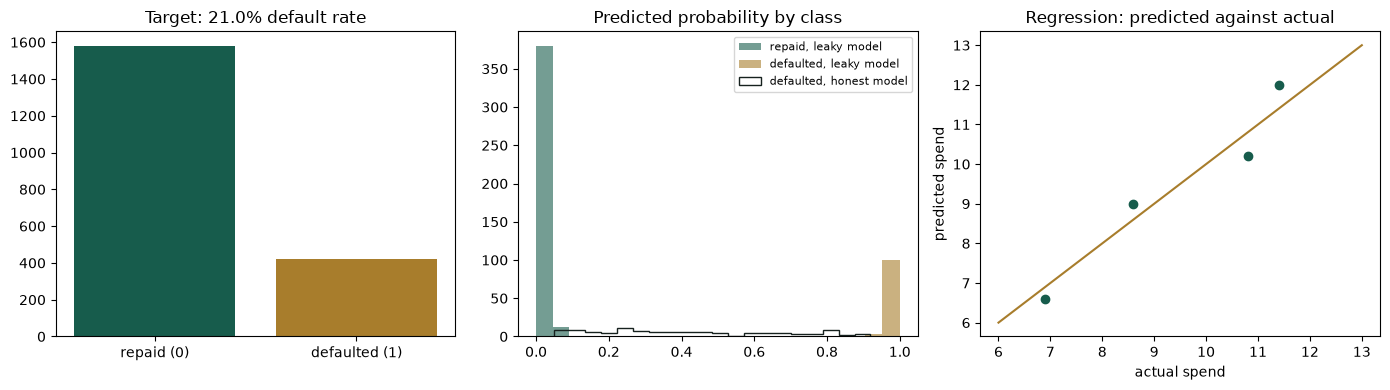

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# 1. the target's distribution
counts = loans["default"].value_counts().sort_index()
axes[0].bar(["repaid (0)", "defaulted (1)"], counts.values, color=["#175C4C", "#A87D2C"])
axes[0].set_title("Target: " + format(loans["default"].mean(), ".1%") + " default rate")
# 2. predicted probabilities by class, leaky model against honest model
leaky = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler()), ("logit", LogisticRegression(max_iter=1000))])
X_all = loans.drop(columns=["default"]); Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_all, y, test_size=0.25, random_state=42, stratify=y)
leaky.fit(Xa_train, ya_train); p_leaky = leaky.predict_proba(Xa_test)[:, 1]
axes[1].hist(p_leaky[ya_test == 0], bins=20, alpha=0.6, color="#175C4C", label="repaid, leaky model")
axes[1].hist(p_leaky[ya_test == 1], bins=20, alpha=0.6, color="#A87D2C", label="defaulted, leaky model")
axes[1].hist(prob[y_test == 1], bins=20, histtype="step", color="#16211E", label="defaulted, honest model")
axes[1].set_title("Predicted probability by class"); axes[1].legend(fontsize=8)
# 3. predicted against actual, Example 2.2 (Northgate, $ thousands)
x_test22 = [45, 65, 75, 90]; y_test22 = [6.9, 8.6, 10.8, 11.4]
pred22 = [1.2 + 0.12 * x for x in x_test22]
axes[2].scatter(y_test22, pred22, color="#175C4C"); axes[2].plot([6, 13], [6, 13], color="#A87D2C")
axes[2].set_xlabel("actual spend"); axes[2].set_ylabel("predicted spend"); axes[2].set_title("Regression: predicted against actual")
plt.tight_layout(); plt.show()

## Section 4 · The library agrees with the hand checks

Examples 2.1 to 2.3 and 2.5 were worked by hand in the chapter. The cells below hand the same fixtures to scikit-learn and compare, to the digits the chapter prints. This is the fourth verb applied in the other direction: the hand check is the reference, and the library is what is being checked.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans

# Example 2.1: Northgate Credit Union, five training customers ($ thousands)
x21 = np.array([40, 50, 60, 70, 80]).reshape(-1, 1); y21 = np.array([6.0, 7.0, 9.0, 9.0, 11.0])
line = LinearRegression().fit(x21, y21)
print("slope", format(line.coef_[0], ".4f"), "intercept", format(line.intercept_, ".4f"), "prediction at 55", format(line.predict([[55]])[0], ".4f"))
assert format(line.coef_[0], ".2f") == "0.12" and format(line.intercept_, ".1f") == "1.2" and format(line.predict([[55]])[0], ".1f") == "7.8"

# Example 2.2: four test customers
x22 = np.array([45, 65, 75, 90]).reshape(-1, 1); y22 = np.array([6.9, 8.6, 10.8, 11.4]); pred22 = line.predict(x22)
print("MAE", format(mean_absolute_error(y22, pred22), ".4f"), "RMSE", format(root_mean_squared_error(y22, pred22), ".4f"), "R2", format(r2_score(y22, pred22), ".4f"))
assert format(mean_absolute_error(y22, pred22), ".4f") == "0.4750" and format(root_mean_squared_error(y22, pred22), ".4f") == "0.4924" and format(r2_score(y22, pred22), ".4f") == "0.9245"

# Example 2.3: Silverbirch Bank, a confusion matrix rebuilt as two label vectors
tp23, fp23, fn23, tn23 = 28, 22, 12, 138
actual = np.array([1] * tp23 + [1] * fn23 + [0] * fp23 + [0] * tn23)
predicted = np.array([1] * tp23 + [0] * fn23 + [1] * fp23 + [0] * tn23)
print("accuracy", format(accuracy_score(actual, predicted), ".3f"), "precision", format(precision_score(actual, predicted), ".3f"), "recall", format(recall_score(actual, predicted), ".3f"), "F1", format(f1_score(actual, predicted), ".4f"))
assert format(accuracy_score(actual, predicted), ".3f") == "0.830" and format(f1_score(actual, predicted), ".4f") == "0.6222"

# Example 2.5: Kestrel Payments, six merchants, k = 2, started at A and B
pts = np.array([[2, 20], [3, 24], [2, 28], [10, 60], [12, 64], [11, 70]], dtype=float)
km = KMeans(n_clusters=2, init=np.array([[2, 20], [3, 24]], dtype=float), n_init=1, random_state=0).fit(pts)
print("labels", km.labels_, "centroids", np.round(km.cluster_centers_, 4), "within-cluster sum of squares", format(km.inertia_, ".4f"))
assert list(km.labels_) == [0, 0, 0, 1, 1, 1] and format(km.inertia_, ".2f") == "85.33"

slope 0.1200 intercept 1.2000 prediction at 55 7.8000
MAE 0.4750 RMSE 0.4924 R2 0.9245
accuracy 0.830 precision 0.560 recall 0.700 F1 0.6222
labels [0 0 0 1 1 1] centroids [[ 2.3333 24.    ]
 [11.     64.6667]] within-cluster sum of squares 85.3333


## Section 5 · Problem 2.10: a pipeline that drops rows and fits the scaler early

The file for this problem has 4,000 loans, 200 of them without a credit score. The specification asked for a stratified 75/25 split, so 3,000 training and 1,000 test rows, with every cleaning step fitted on the training set. The first cell writes the file; the second runs the code the tool returned, with two print lines added so the sizes can be seen; the third is the fix. The flawed code's leaks are its two scaler lines (the scaler learns from every row) and it also drops rows, splits without stratification, and prints accuracy without the baseline.

In [11]:
rng = np.random.default_rng(7)
big = make_loans(n=4000, seed=7).drop(columns=["collections_flag"])
big["credit_score"] = big["credit_score"].where(~big["credit_score"].isna(), big["credit_score"].median())   # start with no gaps
blank = rng.choice(big.index, size=200, replace=False); big.loc[blank, "credit_score"] = np.nan   # then exactly 200 gaps
big.to_csv("loans.csv", index=False)
print(big.shape, "missing scores", int(big["credit_score"].isna().sum()))

(4000, 6) missing scores 200


In [12]:
# --- the code the tool returned (Problem 2.10), with the sizes printed ---
loans = pd.read_csv("loans.csv").dropna()
scaler = StandardScaler().fit(loans.drop(columns=["default"]))
X = scaler.transform(loans.drop(columns=["default"]))
y = loans["default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
print("accuracy", format(model.score(X_test, y_test), ".3f"))
print("rows after dropna", len(loans), "train", len(X_train), "test", len(X_test))
assert (len(loans), len(X_train), len(X_test)) == (3800, 2850, 950)

accuracy 0.817
rows after dropna 3800 train 2850 test 950


In [13]:
# --- the fix: keep every row, split first, one pipeline fitted on the training set ---
loans = pd.read_csv("loans.csv")                        # keep every row; the imputer handles the gaps
X = loans.drop(columns=["default"])
y = loans["default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
model = Pipeline([("impute", SimpleImputer(strategy="median")),
                  ("scale", StandardScaler()),
                  ("logit", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)                            # every step fitted on the training set
tn, fp, fn, tp = confusion_matrix(y_test, model.predict(X_test)).ravel()
print("train", len(X_train), "test", len(X_test), "tp", tp, "fp", fp, "fn", fn, "tn", tn)
train_median = X_train["credit_score"].median(); fill_used = model.named_steps["impute"].statistics_[list(X_train.columns).index("credit_score")]
print("training median", train_median, "fill value used by the pipeline", fill_used)
print("default rate train", format(y_train.mean(), ".3f"), "test", format(y_test.mean(), ".3f"))
assert (len(X_train), len(X_test)) == (3000, 1000) and train_median == fill_used

train 3000 test 1000 tp 59 fp 26 fn 145 tn 770
training median 680.0 fill value used by the pipeline 680.0
default rate train 0.205 test 0.204


## Section 6 · Problems 2.11 to 2.13: the baseline, the standard error, and the unscaled cluster

Problem 2.11 compares a reported accuracy with the majority baseline. Problem 2.12 puts a standard error on the best of five test accuracies. Problem 2.13 shows, on a small synthetic sample, that k-means on raw dollars finds income bands and that standardizing changes what "similar" means.

In [14]:
# Problem 2.11
n11, rate11, acc11 = 5000, 0.02, 0.978
baseline_correct = n11 - int(n11 * rate11); model_correct = int(round(acc11 * n11))
print("baseline", 1 - rate11, "baseline correct", baseline_correct, "model correct", model_correct, "shortfall", baseline_correct - model_correct)
assert baseline_correct - model_correct == 10

# Problem 2.12
accs = [0.841, 0.85, 0.864, 0.857, 0.839]; n12 = 500
best = max(accs); se = (best * (1 - best) / n12) ** 0.5
print("best", best, "standard error", format(se, ".4f"), "spread in standard errors", format((best - min(accs)) / se, ".2f"))
assert format(se, ".4f") == "0.0153"

# Problem 2.13: the two gaps, then a demonstration
sd_income, sd_products, gap_income, gap_products = 25000.0, 1.2, 10000.0, 3
print("raw squared gaps", int(gap_income ** 2), gap_products ** 2, "standardized", format((gap_income / sd_income) ** 2, ".4f"), format((gap_products / sd_products) ** 2, ".4f"))
assert (gap_income / sd_income) ** 2 == 0.16000000000000003 and (gap_products / sd_products) ** 2 == 6.25
rng = np.random.default_rng(13)
income = rng.normal(70000, sd_income, 300); products = rng.choice([1, 2, 3, 4, 5], 300)
cust = np.column_stack([income, products])
raw = KMeans(n_clusters=3, n_init=10, random_state=0).fit(cust)
scaled = KMeans(n_clusters=3, n_init=10, random_state=0).fit(StandardScaler().fit_transform(cust))
print("raw clusters: mean products by cluster", np.round([products[raw.labels_ == c].mean() for c in range(3)], 2), "(the same in every cluster: income bands)")
print("scaled clusters: mean products by cluster", np.round([products[scaled.labels_ == c].mean() for c in range(3)], 2), "(the product count now matters)")

baseline 0.98 baseline correct 4900 model correct 4890 shortfall 10
best 0.864 standard error 0.0153 spread in standard errors 1.63
raw squared gaps 100000000 9 standardized 0.1600 6.2500
raw clusters: mean products by cluster [2.84 3.01 2.62] (the same in every cluster: income bands)
scaled clusters: mean products by cluster [4.41 1.67 2.05] (the product count now matters)


## Closing note

Every figure asserted above came from the chapter's own calc script and was reproduced here by running the code shown beside it. If you change the seed, the loan file changes and so do the counts; the discipline does not. Split before fitting, keep the outcome away from the features, fit the cleaning on the training set, read accuracy beside the baseline, and choose the threshold on costs.